In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [17]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import RandomForestClassifier
from pyspark.sql.types import StructType, StructField, StringType, LongType, DoubleType
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.functions import count, col, when, sum, round
from pyspark.sql.functions import udf, when, col
from pyspark.sql.types import DoubleType
from pyspark.sql.functions import col, sum, round, monotonically_increasing_id

In [18]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("Task4_ML_Pipeline_Jupyter") \
    .getOrCreate()

print("Spark Session Created successfully!")

Spark Session Created successfully!


In [19]:
schema = StructType([
    StructField("event_time", StringType(), True),
    StructField("event_type", StringType(), True),
    StructField("product_id", LongType(), True),
    StructField("category_id", LongType(), True),
    StructField("category_code", StringType(), True),
    StructField("brand", StringType(), True),
    StructField("price", DoubleType(), True),
    StructField("user_id", LongType(), True),
    StructField("user_session", StringType(), True)
])

# Load data
df = spark.read.csv("ecom.csv", schema=schema, header=False)



In [20]:
#Print the schema to verify structural types
df.printSchema()

root
 |-- event_time: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: long (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: long (nullable = true)
 |-- user_session: string (nullable = true)



In [21]:
df.limit(5).toPandas()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,event_time,event_type,NaN,NaN,category_code,brand,NaN,NaN,user_session
1,2019-12-01 00:00:00 UTC,remove_from_cart,5712790.0,1.487580e+18,None,f.o.x,6.27,576802932.0,51d85cb0-897f-48d2-918b-ad63965c12dc
2,2019-12-01 00:00:00 UTC,view,5764655.0,1.487580e+18,None,cnd,29.05,412120092.0,8adff31e-2051-4894-9758-224bfa8aec18
3,2019-12-01 00:00:02 UTC,cart,4958.0,1.487580e+18,None,runail,1.19,494077766.0,c99a50e8-2fac-4c4d-89ec-41c05f114554
4,2019-12-01 00:00:05 UTC,view,5848413.0,1.487580e+18,None,freedecor,0.79,348405118.0,722ffea5-73c0-4924-8e8f-371ff8031af4


In [22]:
sample_df = df.select("event_type", "brand", "price", "user_id").sample(fraction=0.1, seed=42).toPandas()
sample_df.describe()

,price,user_id
count,352856.000000,3.528560e+05
mean,8.906896,5.222684e+08
std,20.127050,8.502210e+07
min,-47.620000,1.180452e+06
25%,2.060000,4.867777e+08
50%,4.220000,5.565578e+08
75%,7.140000,5.828221e+08
max,327.780000,5.954143e+08


In [23]:
# Count null values for every single column to document in your report
null_counts = df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns])
null_counts.toPandas()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,0,0,1,1,3474821,1510289,1,1,779


In [24]:
# Apply cleaning filters to remove invalid rows
df_clean = df.filter(
    df.brand.isNotNull() & 
    (df.brand != '') & 
    df.price.isNotNull() & 
    df.user_id.isNotNull()
)


In [25]:
# Feature Engineering: Create the Target Variable
# 1 = Completed Purchase, 0 = Window Shopping (view/cart)
df_labeled = df_clean.withColumn("label", when(col("event_type") == "purchase", 1).otherwise(0))

print(f"Original Dataset Size: {df.count()} rows")
print(f"Cleaned & Labeled Dataset Size: {df_labeled.count()} rows")

# Preview the clean columns we will use for the ML model
df_labeled.select("event_type", "brand", "price", "user_id", "label").limit(5).toPandas()

Original Dataset Size: 3533287 rows
Cleaned & Labeled Dataset Size: 2022997 rows


,event_type,brand,price,user_id,label
0,remove_from_cart,f.o.x,6.27,576802932,0
1,view,cnd,29.05,412120092,0
2,cart,runail,1.19,494077766,0
3,view,freedecor,0.79,348405118,0
4,view,runail,2.62,560109803,0


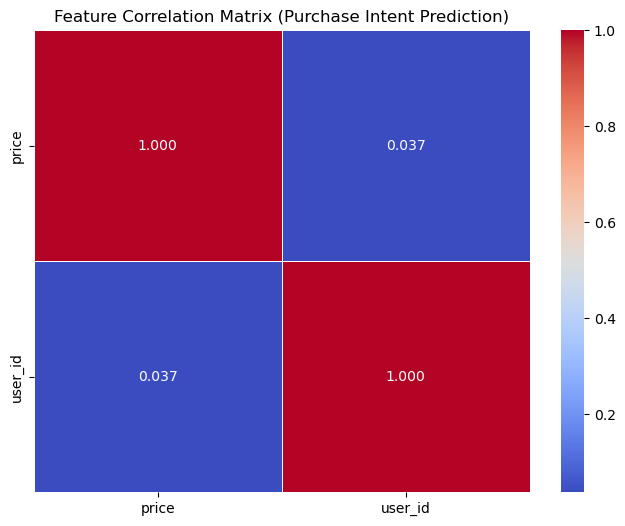

In [26]:
# 1. Convert a 10% sample of the selected columns to a Pandas DataFrame
pandas_sample = df.select("event_type", "brand", "price", "user_id").sample(fraction=0.1, seed=42).toPandas()

# 2. Select only numeric columns for correlation matrix
# Only include numeric columns (price and user_id) for correlation calculation
numeric_columns = pandas_sample.select_dtypes(include=['number'])

# 3. Generate and plot the heatmap using only numeric columns
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_columns.corr(), annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Feature Correlation Matrix (Purchase Intent Prediction)')
plt.show()

Aggregating brand performance metrics in Spark...


/var/folders/6s/svzdr1yn1p36640d7nyphr6r0000gn/T/ipykernel_19268/1301504426.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/6s/svzdr1yn1p36640d7nyphr6r0000gn/T/ipykernel_19268/1301504426.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


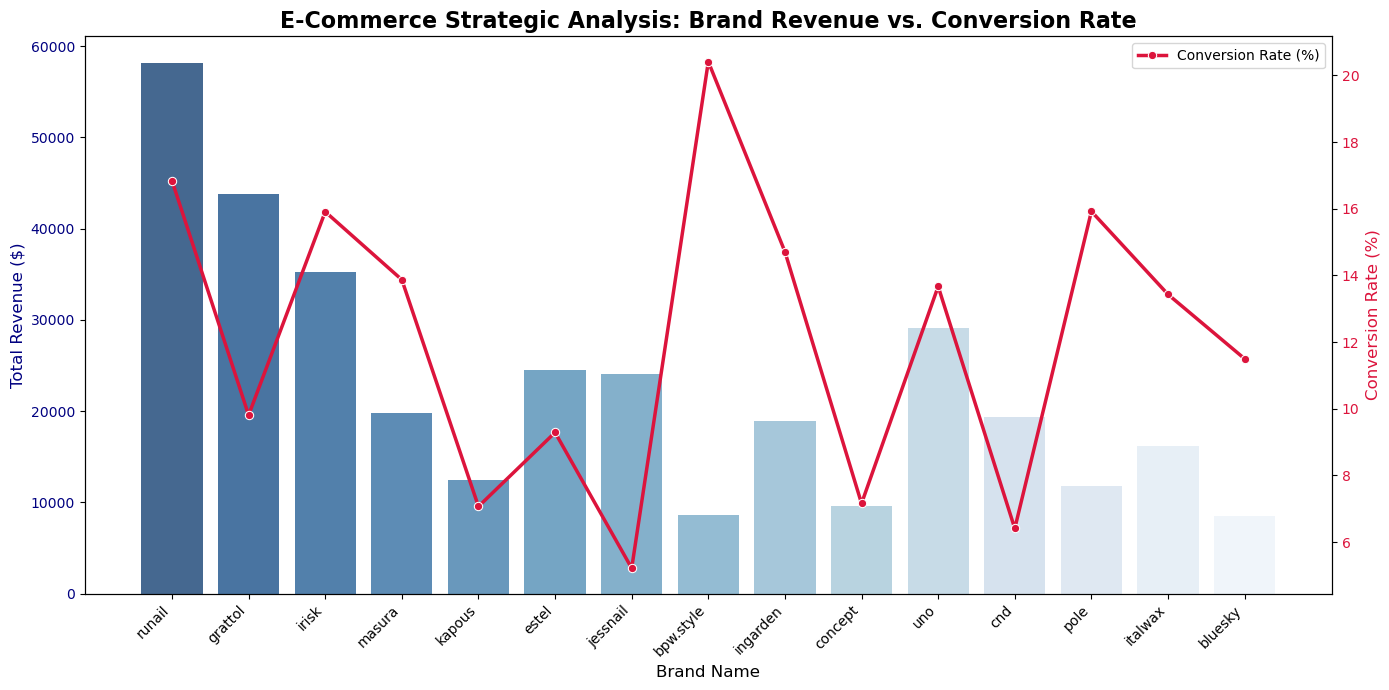

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, when, count, sum, round
print("Aggregating brand performance metrics in Spark...")

# 1. Compute total actions and actual purchases per brand
brand_metrics = df_clean.groupBy("brand").agg(
    count(when(col("event_type") == "view", 1)).alias("total_views"),
    count(when(col("event_type") == "purchase", 1)).alias("total_purchases"),
    round(sum(when(col("event_type") == "purchase", col("price")).otherwise(0)), 2).alias("total_revenue")
)

# 2. Calculate conversion rate percentage: (Purchases / Views) * 100
# Filter for top 15 brands by volume so the chart stays crisp and legible
business_insights_df = brand_metrics.withColumn(
    "conversion_rate_pct", 
    round((col("total_purchases") / col("total_views")) * 100, 2)
).orderBy(col("total_views").desc()).limit(15).toPandas()

# ==============================================================
# PLOTTING THE BUSINESS DECISION CHARTS
# ==============================================================
fig, ax1 = plt.subplots(figsize=(14, 7))

# Chart A: Bar plot showing Revenue per Brand
sns.barplot(
    data=business_insights_df, 
    x="brand", 
    y="total_revenue", 
    ax=ax1, 
    palette="Blues_r", 
    alpha=0.8
)
ax1.set_title("E-Commerce Strategic Analysis: Brand Revenue vs. Conversion Rate", fontsize=16, fontweight='bold')
ax1.set_xlabel("Brand Name", fontsize=12)
ax1.set_ylabel("Total Revenue ($)", fontsize=12, color='navy')
ax1.tick_params(axis='y', labelcolor='navy')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Chart B: Line plot over it mapping the Conversion Rate (Dual Axis)
ax2 = ax1.twinx()
sns.lineplot(
    data=business_insights_df, 
    x="brand", 
    y="conversion_rate_pct", 
    ax=ax2, 
    color="crimson", 
    marker="o", 
    linewidth=2.5, 
    label="Conversion Rate (%)"
)
ax2.set_ylabel("Conversion Rate (%)", fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.tight_layout()
plt.show()

Step 1: Preparing base columns and handling categorical values...


Step 2: Assembling features while handling null values...
Step 3: Splitting dataset into Train (80%) and Test (20%)...
Step 4: Training Random Forest Model...


26/06/19 21:14:15 WARN MemoryStore: Not enough space to cache rdd_149_2 in memory! (computed 5.5 MiB so far)
26/06/19 21:14:15 WARN MemoryStore: Not enough space to cache rdd_149_4 in memory! (computed 8.2 MiB so far)
26/06/19 21:14:15 WARN BlockManager: Persisting block rdd_149_2 to disk instead.
26/06/19 21:14:15 WARN BlockManager: Persisting block rdd_149_4 to disk instead.
26/06/19 21:14:15 WARN MemoryStore: Not enough space to cache rdd_149_7 in memory! (computed 8.2 MiB so far)
26/06/19 21:14:15 WARN BlockManager: Persisting block rdd_149_7 to disk instead.
26/06/19 21:14:15 WARN MemoryStore: Not enough space to cache rdd_149_0 in memory! (computed 8.2 MiB so far)
26/06/19 21:14:15 WARN MemoryStore: Not enough space to cache rdd_149_3 in memory! (computed 8.2 MiB so far)
26/06/19 21:14:15 WARN BlockManager: Persisting block rdd_149_3 to disk instead.
26/06/19 21:14:15 WARN BlockManager: Persisting block rdd_149_0 to disk instead.
26/06/19 21:14:15 WARN MemoryStore: Not enough spa

Step 5: Extracting safe probabilities and applying customized threshold...
Step 6: Calculating Revenue at Risk metrics...


Step 7: Generating Final Chart...


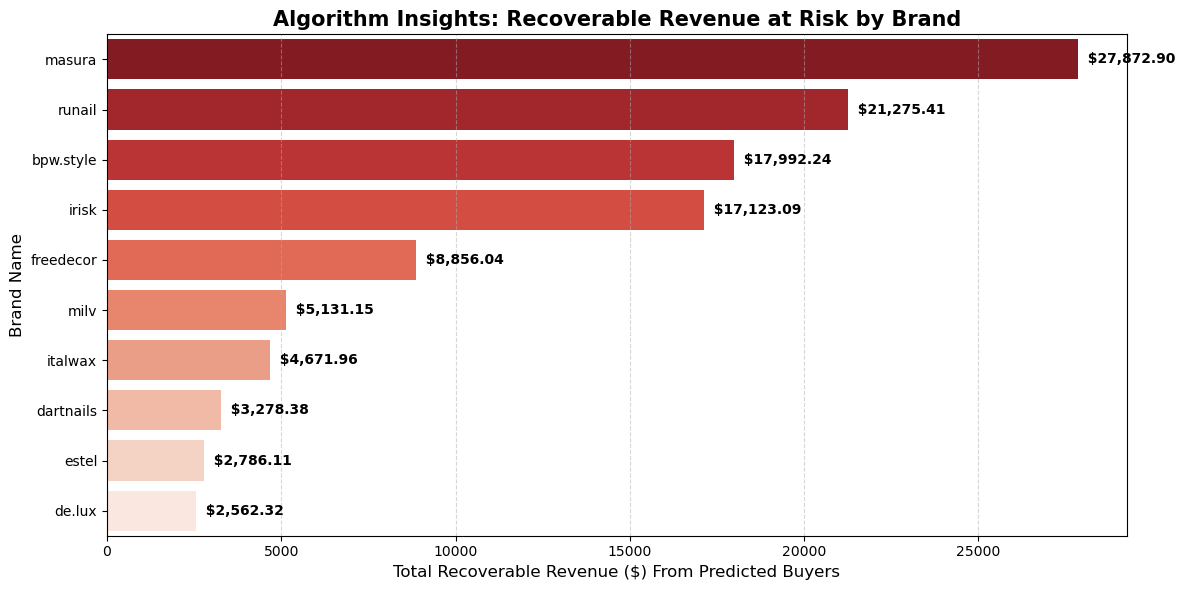

In [39]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.sql.functions import col, sum, round, udf, when
from pyspark.sql.types import DoubleType
import matplotlib.pyplot as plt
import seaborn as sns

print("Step 1: Preparing base columns and handling categorical values...")

# 1. Recreate the label column based on purchase events
df_with_label = df.withColumn("label", when(col("event_type") == "purchase", 1.0).otherwise(0.0))

# 2. Re-run StringIndexer to convert brand strings to frequency indices
indexer = StringIndexer(inputCol="brand", outputCol="brand_index", handleInvalid="skip")
df_indexed = indexer.fit(df_with_label).transform(df_with_label)

# 3. Ensure price and user_id are formatted correctly as numbers
df_ready = df_indexed.withColumn("price", col("price").cast("double")) \
                     .withColumn("user_id", col("user_id").cast("double"))

print("Step 2: Assembling features while handling null values...")
# FIXED: Added handleInvalid="skip" to bypass rows containing null values safely
assembler = VectorAssembler(
    inputCols=["brand_index", "price", "user_id"], 
    outputCol="features",
    handleInvalid="skip"
)
final_pipeline_data = assembler.transform(df_ready).select("features", "label", "brand", "price")

print("Step 3: Splitting dataset into Train (80%) and Test (20%)...")
train_data, test_data = final_pipeline_data.randomSplit([0.8, 0.2], seed=42)

print("Step 4: Training Random Forest Model...")
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50, maxBins=256, seed=42)
rf_model = rf.fit(train_data)
predictions = rf_model.transform(test_data)

print("Step 5: Extracting safe probabilities and applying customized threshold...")
extract_prob_udf = udf(lambda v: float(v[1]), DoubleType())
predictions_with_prob = predictions.withColumn("prob_purchase", extract_prob_udf(col("probability")))

custom_threshold = 0.06
adjusted_predictions = predictions_with_prob.withColumn(
    "adjusted_prediction", 
    when(col("prob_purchase") >= custom_threshold, 1.0).otherwise(0.0)
)

print("Step 6: Calculating Revenue at Risk metrics...")
# Target users flagged by the model who haven't completed checkouts yet
high_intent_abandonment = adjusted_predictions.filter(
    (col("adjusted_prediction") == 1.0) & (col("label") == 0)
)

revenue_at_risk = high_intent_abandonment.groupBy("brand").agg(
    round(sum("price"), 2).alias("Recoverable_Revenue")
).orderBy(col("Recoverable_Revenue").desc()).limit(10).toPandas()

# ==============================================================
# PLOTTING THE DIAGRAM
# ==============================================================
print("Step 7: Generating Final Chart...")
plt.figure(figsize=(12, 6))
sns.barplot(
    data=revenue_at_risk, 
    x='Recoverable_Revenue', 
    y='brand', 
    palette='Reds_r',
    hue='brand',
    legend=False
)

plt.title('Algorithm Insights: Recoverable Revenue at Risk by Brand', fontsize=15, fontweight='bold')
plt.xlabel('Total Recoverable Revenue ($) From Predicted Buyers', fontsize=12)
plt.ylabel('Brand Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for index, value in enumerate(revenue_at_risk['Recoverable_Revenue']):
    plt.text(value, index, f'  ${value:,.2f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [43]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.functions import udf, when, col
from pyspark.sql.types import DoubleType
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("Step 1: Preparing base columns and index transformations...")
# 1. Recreate the target purchase label
df_with_label = df.withColumn("label", when(col("event_type") == "purchase", 1.0).otherwise(0.0))

# 2. Convert brand strings to frequency-based numeric indices
indexer = StringIndexer(inputCol="brand", outputCol="brand_index", handleInvalid="skip")
df_indexed = indexer.fit(df_with_label).transform(df_with_label)

# 3. Formally cast features to correct numeric types
df_ready = df_indexed.withColumn("price", col("price").cast("double")) \
                     .withColumn("user_id", col("user_id").cast("double"))

print("Step 2: Assembling features and skipping null rows safely...")
# Added handleInvalid="skip" to protect the assembly phase from raw dataset nulls
assembler = VectorAssembler(
    inputCols=["brand_index", "price", "user_id"], 
    outputCol="features",
    handleInvalid="skip"
)
final_data = assembler.transform(df_ready).select("features", "label")

print("Step 3: Splitting dataset into Train (80%) and Test (20%)...")
train_data, test_data = final_data.randomSplit([0.8, 0.2], seed=42)

print("Step 4: Training Spark Random Forest Model (Accommodating 252 brands)...")
# Setting maxBins=256 keeps Spark from crashing on high categorical variations
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50, maxBins=256, seed=42)
rf_model = rf.fit(train_data)

print("Step 5: Generating Raw Probabilities on Test Data...")
predictions = rf_model.transform(test_data)

# Extract the purchase probability using our safe UDF
extract_prob_udf = udf(lambda v: float(v[1]), DoubleType())
predictions_with_prob = predictions.withColumn("prob_purchase", extract_prob_udf(col("probability")))

# Apply the optimized baseline threshold to handle class imbalance
custom_threshold = 0.06
adjusted_predictions = predictions_with_prob.withColumn(
    "adjusted_prediction", 
    when(col("prob_purchase") >= custom_threshold, 1.0).otherwise(0.0)
)

print("Step 6: Computing Performance Metrics...")
tp = adjusted_predictions.filter((adjusted_predictions.adjusted_prediction == 1) & (adjusted_predictions.label == 1)).count()
fp = adjusted_predictions.filter((adjusted_predictions.adjusted_prediction == 1) & (adjusted_predictions.label == 0)).count()
tn = adjusted_predictions.filter((adjusted_predictions.adjusted_prediction == 0) & (adjusted_predictions.label == 0)).count()
fn = adjusted_predictions.filter((adjusted_predictions.adjusted_prediction == 0) & (adjusted_predictions.label == 1)).count()

accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (fn + tp) if (fn + tp) > 0 else 0

evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
auc = evaluator.evaluate(predictions)

print("\n=======================================================")
print("             RANDOM FOREST MODEL METRICS               ")
print("=======================================================")
print(f"Model Area Under ROC (AUC): {auc:.4f}")
print(f"Adjusted Accuracy:          {accuracy:.4f}")
print(f"Adjusted Precision:         {precision:.4f}")
print(f"Adjusted Recall:            {recall:.4f}")
print("=======================================================\n")



Step 1: Preparing base columns and index transformations...
Step 2: Assembling features and skipping null rows safely...
Step 3: Splitting dataset into Train (80%) and Test (20%)...
Step 4: Training Spark Random Forest Model (Accommodating 252 brands)...


26/06/19 21:17:17 WARN MemoryStore: Not enough space to cache rdd_361_4 in memory! (computed 8.2 MiB so far)
26/06/19 21:17:17 WARN BlockManager: Persisting block rdd_361_4 to disk instead.
26/06/19 21:17:17 WARN MemoryStore: Not enough space to cache rdd_361_1 in memory! (computed 18.5 MiB so far)
26/06/19 21:17:17 WARN BlockManager: Persisting block rdd_361_1 to disk instead.
26/06/19 21:17:17 WARN MemoryStore: Not enough space to cache rdd_361_6 in memory! (computed 12.3 MiB so far)
26/06/19 21:17:17 WARN BlockManager: Persisting block rdd_361_6 to disk instead.
26/06/19 21:17:17 WARN MemoryStore: Not enough space to cache rdd_361_0 in memory! (computed 3.5 MiB so far)
26/06/19 21:17:17 WARN BlockManager: Persisting block rdd_361_0 to disk instead.
26/06/19 21:17:17 WARN MemoryStore: Not enough space to cache rdd_361_5 in memory! (computed 12.3 MiB so far)
26/06/19 21:17:17 WARN BlockManager: Persisting block rdd_361_5 to disk instead.
26/06/19 21:17:17 WARN MemoryStore: Not enough 

Step 5: Generating Raw Probabilities on Test Data...
Step 6: Computing Performance Metrics...


[Stage 146:>                                                      (0 + 10) / 10]


             RANDOM FOREST MODEL METRICS               
Model Area Under ROC (AUC): 0.5698
Adjusted Accuracy:          0.6934
Adjusted Precision:         0.0851
Adjusted Recall:            0.4220

